# <center>Support Vector Machine (SVM)

## Table of Algorithms
### Linear SVM
1. Hard-margin SVM (SGD)
2. Soft-margin SVM (GD) 
3. Soft-margin SVM (SGD)
4. Soft-margin SVM (Mini-batch GD)
### Kernel SVM
5. Kernel SVM (RBF)

---

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hard_margin_sgd import hinge_loss
from soft_margin_gd import hinge_loss_C

Importing data

In [2]:
import os
os.path.abspath(os.path.join(os.path.dirname('02_logistic_regression'), '..'))

bezdekIris = '../data/iris/bezdekIris.data'
df = pd.read_csv(bezdekIris)

---

Checking data

In [3]:
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [6]:
df['class'] = df['class'].map({'Iris-setosa': 1, 
                               'Iris-versicolor': -1, 
                               'Iris-virginica': -1})

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [8]:
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,1
1,4.7,3.2,1.3,0.2,1
2,4.6,3.1,1.5,0.2,1
3,5.0,3.6,1.4,0.2,1
4,5.4,3.9,1.7,0.4,1
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,-1
145,6.3,2.5,5.0,1.9,-1
146,6.5,3.0,5.2,2.0,-1
147,6.2,3.4,5.4,2.3,-1


---

Visualizing data

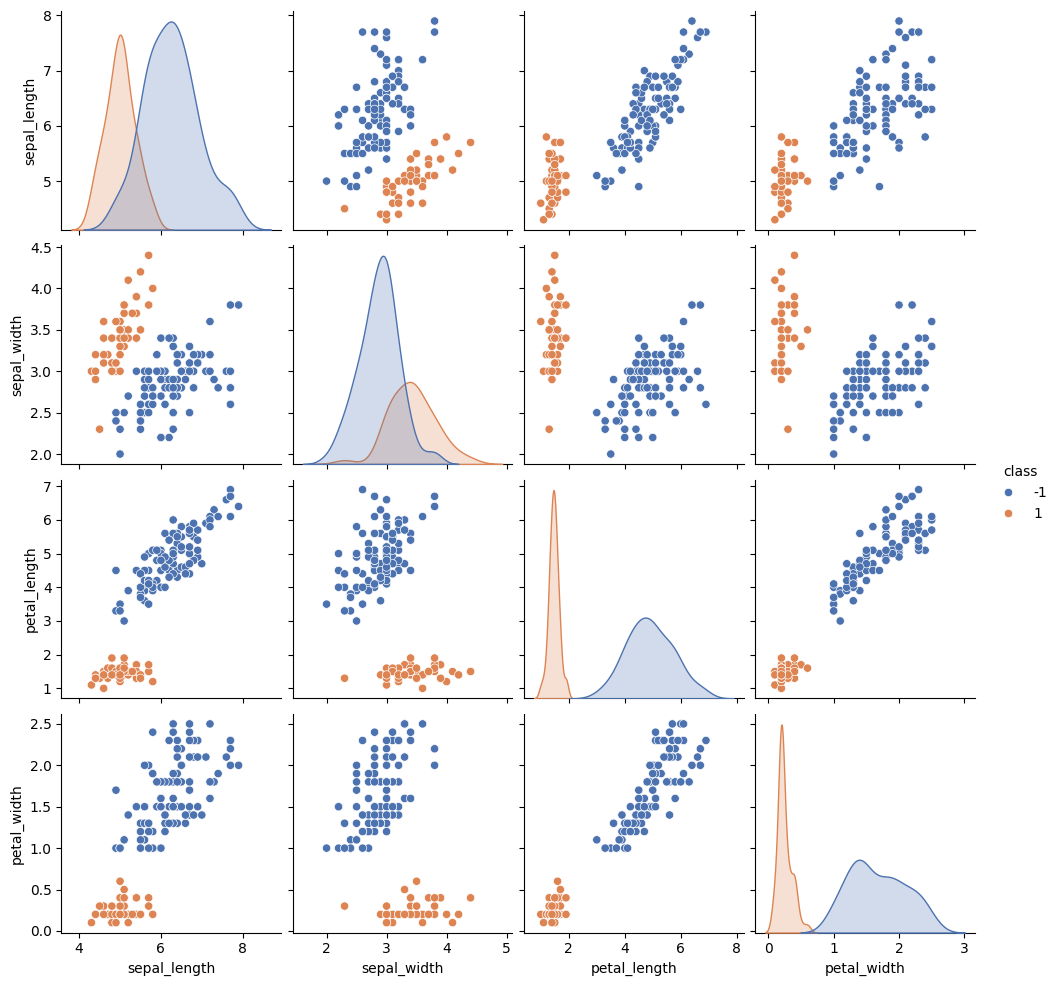

In [9]:
sns.pairplot(data=df, hue='class', palette='deep')

---

### **Hard margin stochastic gradient descent**

For 0 epoch
Loss: [0.46483145]
For 1 epoch
Loss: [0.45138968]
For 2 epoch
Loss: [0.44788797]
For 3 epoch
Loss: [0.44081101]
For 4 epoch
Loss: [0.43373364]
For 5 epoch
Loss: [0.42665586]
For 6 epoch
Loss: [0.41957767]
For 7 epoch
Loss: [0.41252398]
For 8 epoch
Loss: [0.40702595]
For 9 epoch
Loss: [0.3997735]
For 10 epoch
Loss: [0.39257516]
For 11 epoch
Loss: [0.38544036]
For 12 epoch
Loss: [0.37979283]
For 13 epoch
Loss: [0.37247989]
For 14 epoch
Loss: [0.36516666]
For 15 epoch
Loss: [0.3594221]
For 16 epoch
Loss: [0.35201216]
For 17 epoch
Loss: [0.34615341]
For 18 epoch
Loss: [0.33873777]
For 19 epoch
Loss: [0.3314484]
For 20 epoch
Loss: [0.32548194]
For 21 epoch
Loss: [0.31821874]
For 22 epoch
Loss: [0.31095537]
For 23 epoch
Loss: [0.30498606]
For 24 epoch
Loss: [0.29772203]
For 25 epoch
Loss: [0.29052458]
For 26 epoch
Loss: [0.28448972]
For 27 epoch
Loss: [0.27732051]
For 28 epoch
Loss: [0.27123478]
For 29 epoch
Loss: [0.26508308]
For 30 epoch
Loss: [0.25776778]
For 31 epoch
Loss: [0

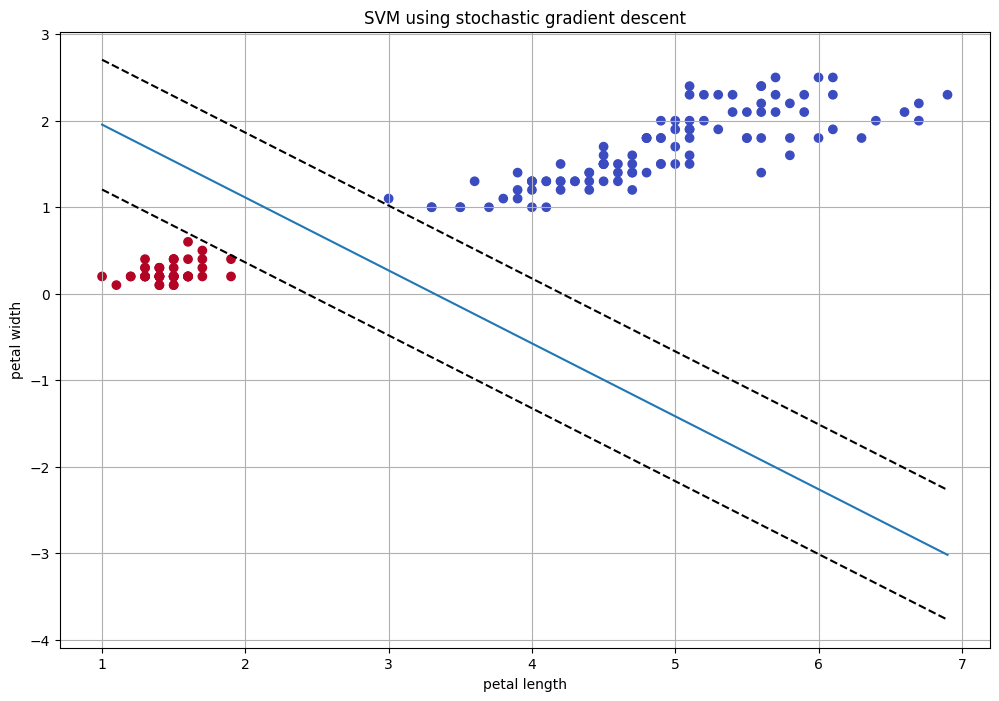

In [10]:
from hard_margin_sgd import Hard_margin_SGD

X = df[['petal_length', 'petal_width']].to_numpy()

y = df['class'].to_numpy()

hard_margin_sgd = Hard_margin_SGD()
hard_margin_sgd.fit(X, y, max_iters=1000, lr=0.001, stats=True)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('SVM using stochastic gradient descent')

w1 = hard_margin_sgd.weights[0]
w2 = hard_margin_sgd.weights[1]
b = hard_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.plot(x1, x2 + 0.75, '--', color='black')
plt.plot(x1, x2 - 0.75, '--', color='black')

---

### **Soft margin gradient descent**

For 0 epochs loss:
78.2975436328025
For 1 epochs loss:
73.33440842087337
For 2 epochs loss:
75.54548080923925
For 3 epochs loss:
75.12394347177684
For 4 epochs loss:
72.79392500299758
For 5 epochs loss:
76.9133456900895
For 6 epochs loss:
70.04287607526975
For 7 epochs loss:
78.7026150649744
For 8 epochs loss:
67.29233388729031
For 9 epochs loss:
80.49175158561162
For 10 epochs loss:
64.66393646537692
For 11 epochs loss:
78.78903637387243
For 12 epochs loss:
65.71722502752966
For 13 epochs loss:
79.7093147924167
For 14 epochs loss:
64.13546398368403
For 15 epochs loss:
77.57535869269327
For 16 epochs loss:
65.60064384004075
For 17 epochs loss:
78.49555247843914
For 18 epochs loss:
64.00587396547084
For 19 epochs loss:
76.79259457440108
For 20 epochs loss:
65.0292613058904
For 21 epochs loss:
76.8405041642755
For 22 epochs loss:
64.31142483177045
For 23 epochs loss:
76.01161602590979
For 24 epochs loss:
64.47562938612347
For 25 epochs loss:
75.62759241961814
For 26 epochs loss:
64.19777

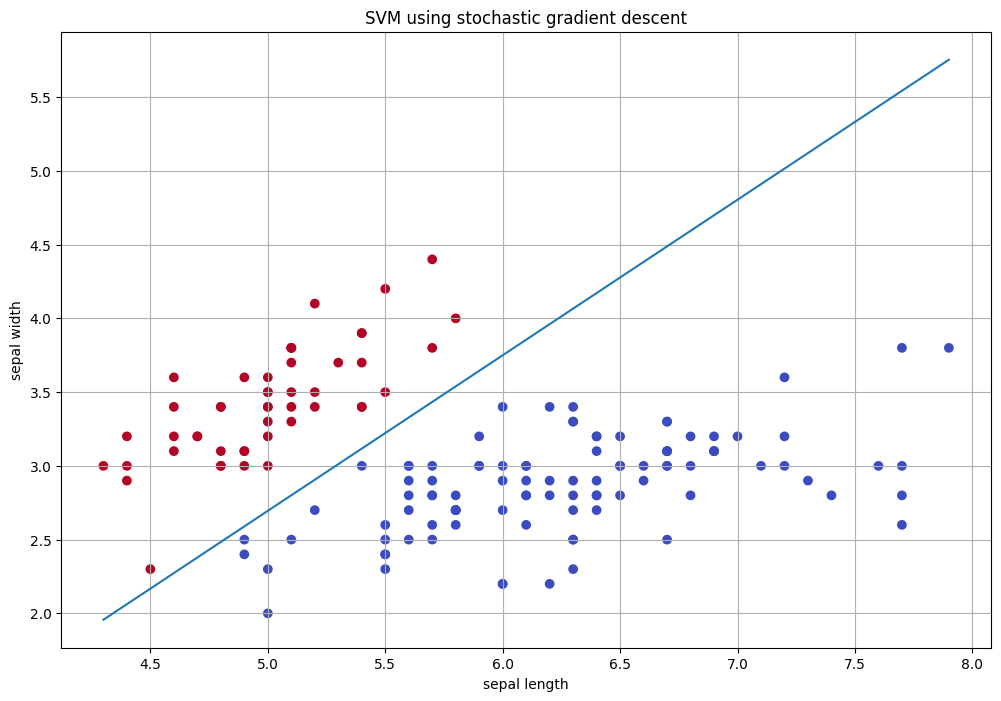

In [11]:
from soft_margin_gd import Soft_margin_GD
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_gd = Soft_margin_GD()
soft_margin_gd.fit(X, y, max_iters=1000, lr=0.0001, stats=True, C=100)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_gd.weights[0]
w2 = soft_margin_gd.weights[1]
b = soft_margin_gd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)

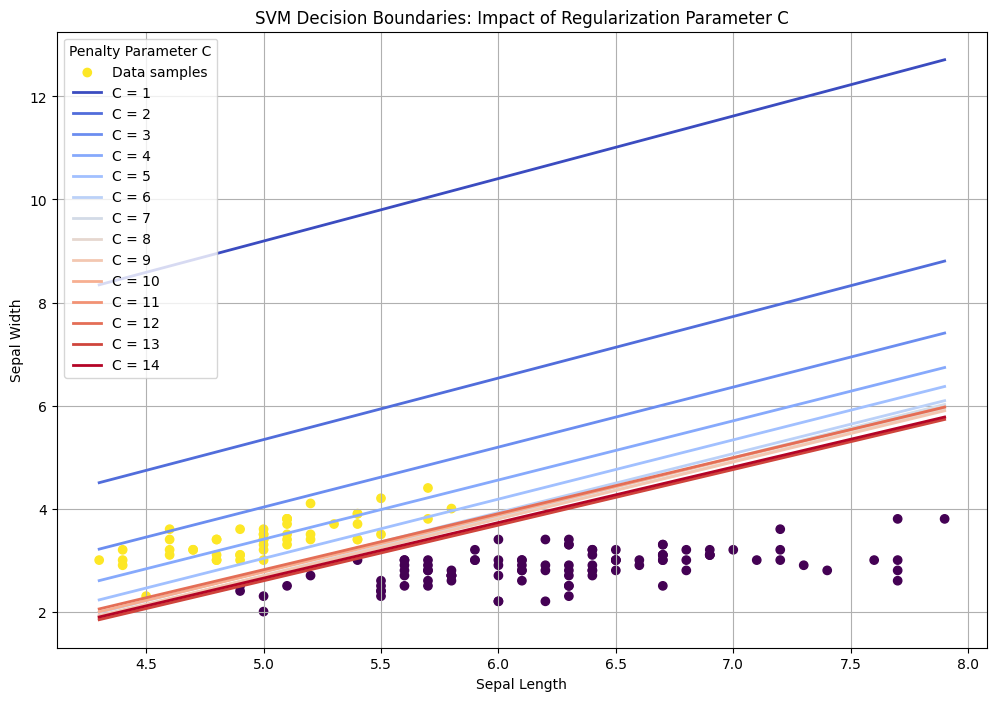

In [12]:
# === C test ===
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()


cs = [i for i in range(1, 15)]
c_test = Soft_margin_GD()

num_plots = len(cs)
colormap = plt.cm.coolwarm
colors = [colormap(i) for i in np.linspace(0, 1, num_plots)]

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='Data samples')

loss_test = []

for idx, c in enumerate(cs):
    c_test.fit(X, y, max_iters=1000, lr=0.001, stats=False, C=c)

    w = c_test.weights.flatten()
    b = c_test.bias

    a_slope = -(w[0] / w[1])
    intercept = -(b / w[1])

    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = (a_slope * x_vals) + intercept
    
    plt.plot(x_vals, y_vals, label=f'C = {c}', color=colors[idx], linewidth=2)

    current_loss = hinge_loss(X, y, c_test.weights, c_test.bias) 
    loss_test.append(current_loss)

plt.title('SVM Decision Boundaries: Impact of Regularization Parameter C',)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title="Penalty Parameter C")
plt.grid()


---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
4.674164901389998
For 1 epochs loss:
3.4493438685863875
For 2 epochs loss:
2.8895652559230545
For 3 epochs loss:
2.4090584006852476
For 4 epochs loss:
1.8689618202434324
For 5 epochs loss:
5.695158118374484
For 6 epochs loss:
1.7314242526958634
For 7 epochs loss:
3.4278815110233753
For 8 epochs loss:
2.662646007051215
For 9 epochs loss:
1.898542385942777
For 10 epochs loss:
2.372490817958199
For 11 epochs loss:
3.774381939969429
For 12 epochs loss:
1.638023523106195
For 13 epochs loss:
1.7728809148289744
For 14 epochs loss:
1.1813321104056378
For 15 epochs loss:
1.2085946267535346
For 16 epochs loss:
2.292265605643684
For 17 epochs loss:
1.723693665911039
For 18 epochs loss:
1.1734089398151435
For 19 epochs loss:
0.8128187910773467
For 20 epochs loss:
4.677386230843049
For 21 epochs loss:
1.9123075643457028
For 22 epochs loss:
3.1336326708920756
For 23 epochs loss:
2.374536362449753
For 24 epochs loss:
2.6286780208196765
For 25 epochs loss:
1.751175230190847
For 26 e

(np.float64(0.5), np.float64(7.1), np.float64(4.0), np.float64(8.0))

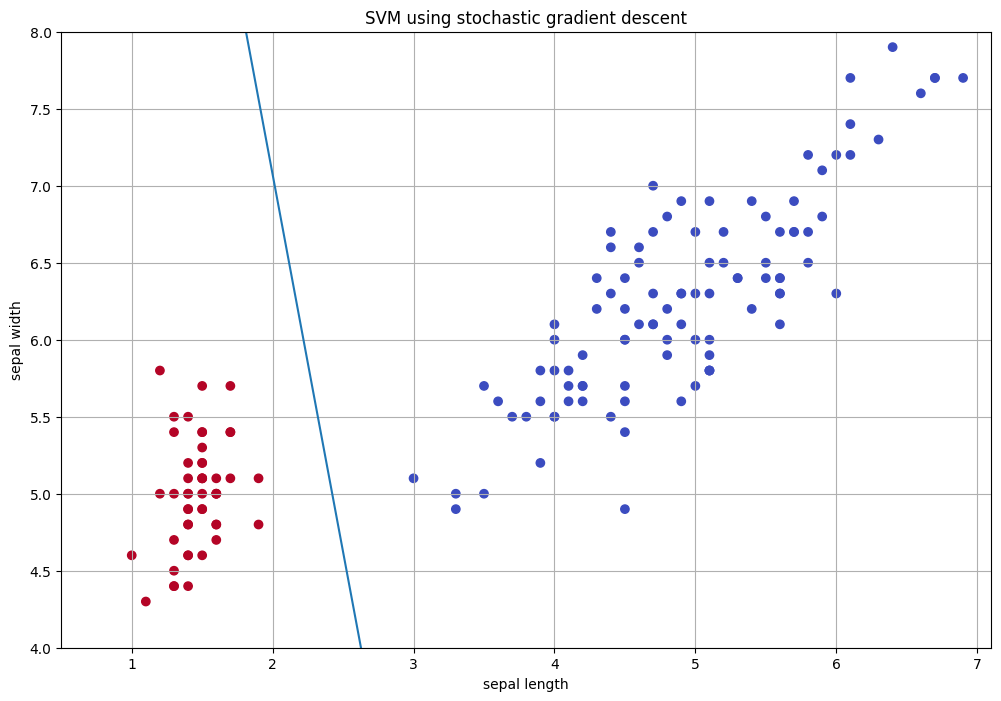

In [20]:
from soft_margin_sgd import Soft_margin_SGD
X = df[['petal_length', 'sepal_length']].to_numpy()
y = df['class'].to_numpy()
soft_margin_sgd = Soft_margin_SGD()
soft_margin_sgd.fit(X, y, max_iters=1000, lr=0.003, stats=True, C=8)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_sgd.weights[0]
w2 = soft_margin_sgd.weights[1]
b = soft_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0.5, 7.1, 4, 8])

---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
6.518482522927089
For 1 epochs loss:
5.284109185512215
For 2 epochs loss:
5.011887722221583
For 3 epochs loss:
4.909838167244047
For 4 epochs loss:
4.847722753842195
For 5 epochs loss:
4.712058908791813
For 6 epochs loss:
4.624222890299416
For 7 epochs loss:
4.557496550236625
For 8 epochs loss:
4.4401294130979245
For 9 epochs loss:
4.35727059257217
For 10 epochs loss:
4.275734329084697
For 11 epochs loss:
4.187066467729865
For 12 epochs loss:
4.101635812914777
For 13 epochs loss:
4.024020534777003
For 14 epochs loss:
3.9529752566242253
For 15 epochs loss:
3.875659257483072
For 16 epochs loss:
3.795793821249617
For 17 epochs loss:
3.7240896427000756
For 18 epochs loss:
3.6536792553094246
For 19 epochs loss:
3.5853417644122616
For 20 epochs loss:
3.517159588762426
For 21 epochs loss:
3.448638295571509
For 22 epochs loss:
3.385590855370913
For 23 epochs loss:
3.3193575794217747
For 24 epochs loss:
3.257039453213136
For 25 epochs loss:
3.200696108325917
For 26 epochs los

(np.float64(0.0), np.float64(2.6), np.float64(1.8), np.float64(4.6))

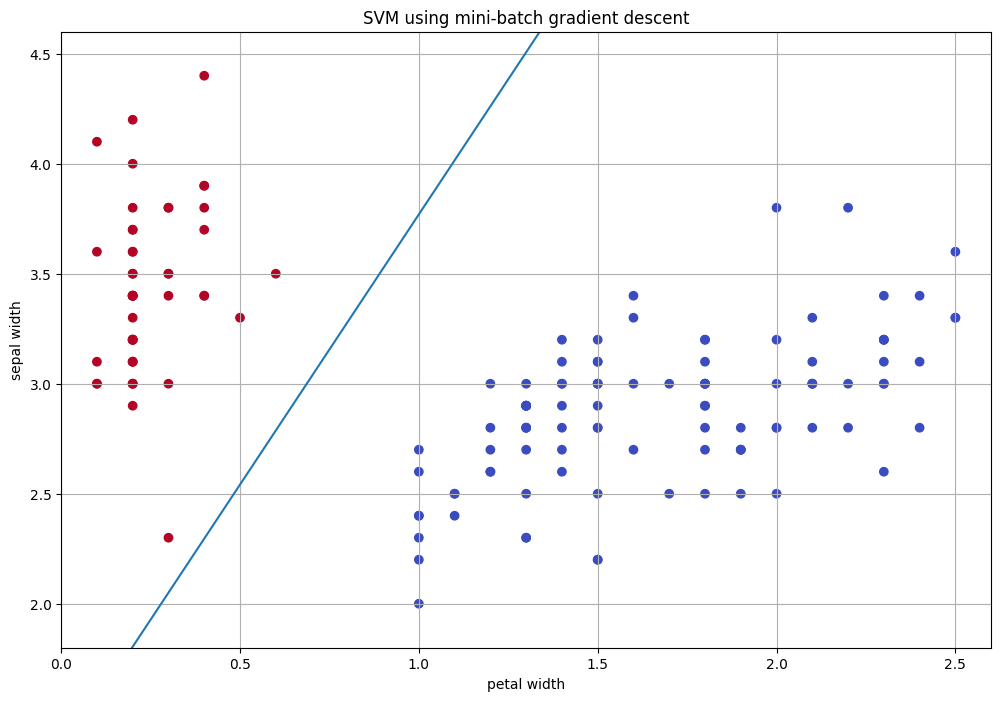

In [14]:
from soft_margin_mini import Soft_margin_MINI
X = df[['petal_width', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_mini = Soft_margin_MINI()
soft_margin_mini.fit(X, y, max_iters=1000, lr=0.001, stats=True, C=8)

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal width')
plt.ylabel('sepal width')
plt.title('SVM using mini-batch gradient descent')

w1 = soft_margin_mini.weights[0]
w2 = soft_margin_mini.weights[1]
b = soft_margin_mini.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0, 2.6, 1.8, 4.6])

---

### **Kernel SVM (RBF)** 

In [15]:
from kernel_svm_rbf import Kernel_svm_RBF

X = df[['petal_width', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()

svm_rbf = Kernel_svm_RBF()
svm_rbf.fit(X, y, max_iters=100, stats=True, C=0.01, gamma=0.5)

Loss for 0 epochs: [[0.52321946]]
Loss for 1 epochs: [[0.76983785]]
Loss for 2 epochs: [[0.89605946]]
Loss for 3 epochs: [[0.96860931]]
Loss for 4 epochs: [[0.97388036]]
Loss for 5 epochs: [[0.9848216]]
Loss for 6 epochs: [[0.9801631]]
Loss for 7 epochs: [[1.0056786]]
Loss for 8 epochs: [[1.01581336]]
Loss for 9 epochs: [[1.01648462]]
Loss for 10 epochs: [[1.02968516]]
Loss for 11 epochs: [[1.02968516]]
Loss for 12 epochs: [[1.03488223]]
Loss for 13 epochs: [[1.04011454]]
Loss for 14 epochs: [[1.04016373]]
Loss for 15 epochs: [[1.03484934]]
Loss for 16 epochs: [[1.01928332]]
Loss for 17 epochs: [[1.01950906]]
Loss for 18 epochs: [[1.02507008]]
Loss for 19 epochs: [[1.0239548]]
Loss for 20 epochs: [[1.02935804]]
Loss for 21 epochs: [[1.02373786]]
Loss for 22 epochs: [[1.02937015]]
Loss for 23 epochs: [[1.02937015]]
Loss for 24 epochs: [[1.03357695]]
Loss for 25 epochs: [[1.02830667]]
Loss for 26 epochs: [[1.02892862]]
Loss for 27 epochs: [[1.02835992]]
Loss for 28 epochs: [[1.02844304]]

---